In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Newton's Method Optimization
### Single Variable
- Implement the <b>Gradient decent and Newton's method</b> as a function and find the minimum of the following function:
    - $𝒇(𝒙)=𝒙^𝟐−𝟏𝟓𝒙+𝟏$,        
- Draw the functions and check out the minimum.
- Draw the 1st derivative of the function and check out the root.
- Draw 2nd derivative of the function and check out the sign at the minimum.
- The stop condition is grad < epsilon.
- Try different epsilons and initial conditions.
- Compare the results with Gradient descent.
##### The function should return the solution and the gradient.

##### Notes:
- You will need to pass the expression of the function, first, and second derivatives to the optimizer.
- You can use lambda expression to construct the function, first, and second derivatives.

In [21]:
f = lambda x: x**2 - 15*x +1
Df = lambda x: 2*x -15
DDf = lambda x: 2

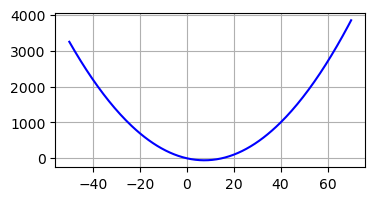

In [19]:
x = np.linspace(-50, 70, 200)
y1=f(x)
plt.figure(figsize=(4, 2))
plt.plot(x,y1,'b-')
plt.grid()
plt.show()

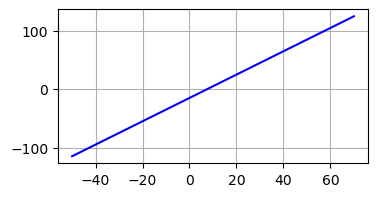

In [23]:
y2=Df(x)
plt.figure(figsize=(4, 2))
plt.plot(x,y2,'b-')
plt.grid()
plt.show()

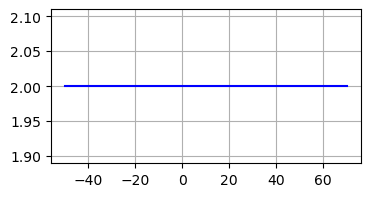

In [30]:
plt.figure(figsize=(4, 2))
plt.plot(x, np.full_like(x, 2), 'b-')
plt.grid()
plt.show()

In [87]:
def GD_single(f,Df,alpha, x0, epsilon):
    x=x0
    iters=0
    for i in range(10000):
        x=x-alpha*Df(x)
        iters=i+1
        if Df(x)<=epsilon:
            break
    print(f"Found solution after {iters} iterations")
    print(f"X_min = {x}")
    print(f"Gradient = {Df(x)}")

In [88]:
GD_single(f,Df,alpha=0.01,x0=40,epsilon=0.1)

Found solution after 321 iterations
X_min = 7.549596800192111
Gradient = 0.09919360038422198


In [89]:
def Newton_single(f,Df,DDf, x0, epsilon,alpha=1):
    x=x0
    iters=0
    for i in range(10000):
        x=x-alpha*(Df(x)/DDf(x))
        iters=i+1
        if Df(x)<=epsilon:
            break
    print(f"Found solution after {iters} iterations")
    print(f"X_min = {x}")
    print(f"Gradient = {Df(x)}")

In [91]:
Newton_single(f,Df,DDf,x0=40,epsilon=0.1)

Found solution after 1 iterations
X_min = 7.5
Gradient = 0.0


In [92]:
Newton_single(f,Df,DDf,x0=40,epsilon=0.1,alpha=0.8)

Found solution after 5 iterations
X_min = 7.5104
Gradient = 0.020799999999999486


### Multi Variable
- Implement the <b>Gradient decent and Newton's method</b> as a function and find the minimum of the following function:
    - $𝒇(𝒙)=𝒙^𝟐+y^2$
    - $𝒇(𝒙)=𝒙^𝟐+xy+y^2$  
    - $𝒇(𝒙)=𝒙^𝟐y$ 
- The stop condition is grad < epsilon.
- Try different epsilons and initial conditions.
- Compare the results with Gradient descent.
##### The function shgould return the solution and the gradient.

In [79]:
from sympy import *
from sympy.plotting import plot3d

$𝒇(𝒙)=𝒙^𝟐+y^2$

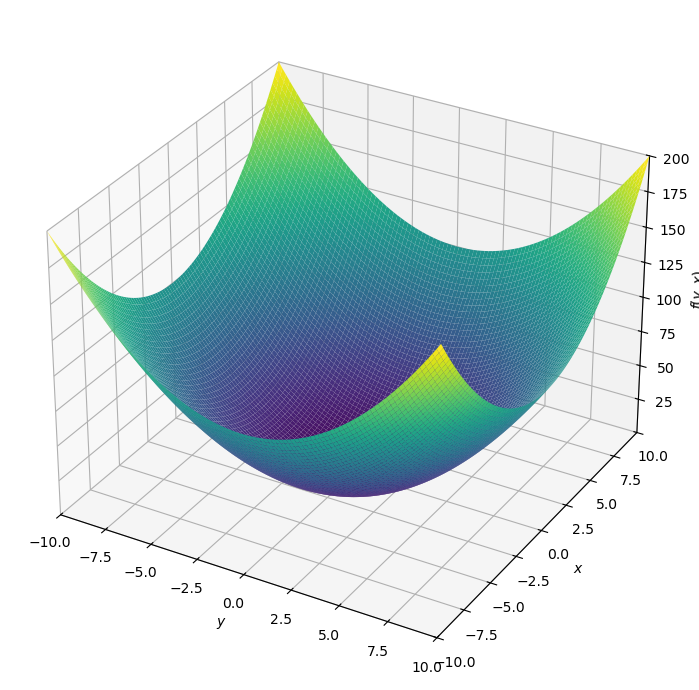

In [80]:
x,y = symbols('x y')
f = x**2 + y**2
plot3d(f,size=(10,7))
plt.show()

$𝒇(𝒙)=𝒙^𝟐+xy+y^2$  

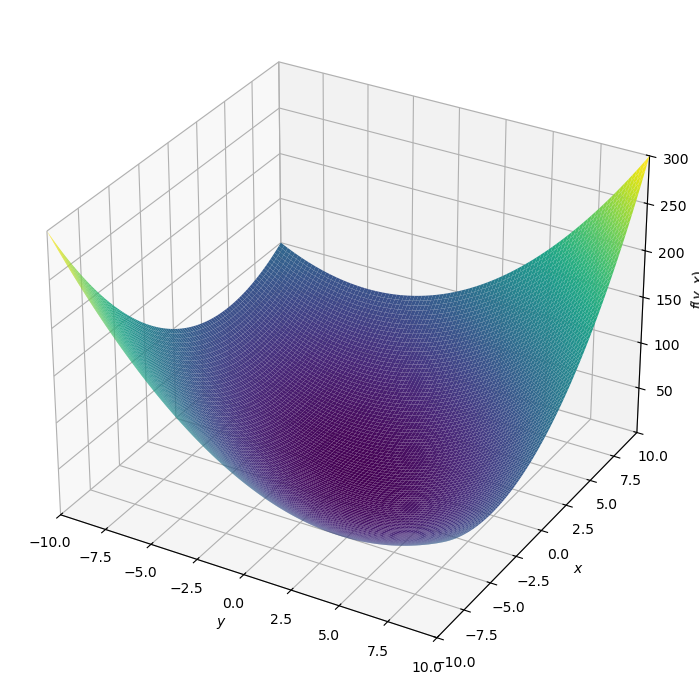

In [81]:
x,y = symbols('x y')
f = x**2 + x * y + y**2
plot3d(f,size=(10,7))
plt.show()

$𝒇(𝒙)=𝒙^𝟐y$ 

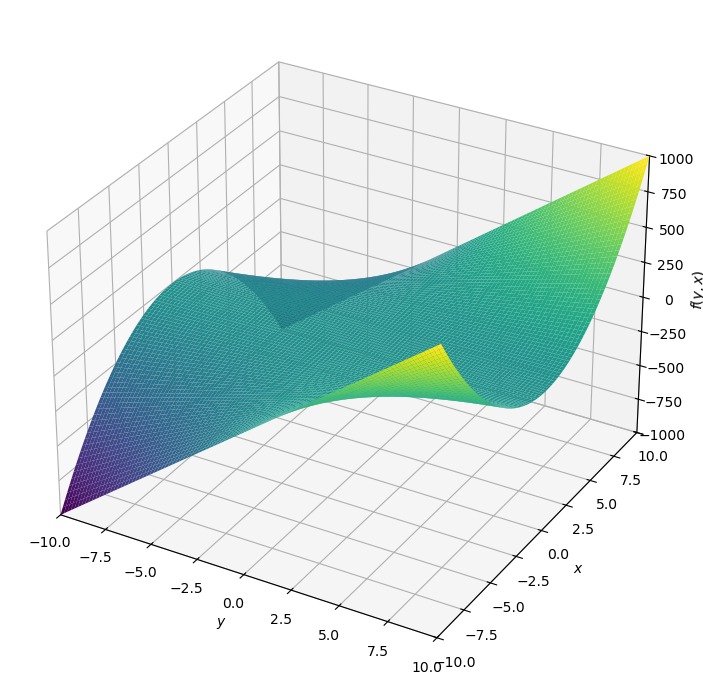

In [83]:
x,y = symbols('x y')
f = x**2 * y
plot3d(f,size=(10,7))
plt.show()

In [123]:
f_1 = lambda x: x**2  + y**2
Df_1 = lambda X: np.array([2*X[0],2*X[1]])
DDf_1 = lambda X: np.array([[2,0],
                         [0,2]])

In [131]:
def GD(f,Df,alpha, x0, epsilon):
    x = np.array(x0, dtype=float)
    iters=0
    for i in range(10000):
        gradient=np.linalg.norm(Df(x))
        if gradient<epsilon:
            break
        x=x-alpha*Df(x)
        iters=i+1
    print(f"Found solution after {iters} iterations")
    print(f"xy_min = {x}")
    print(f"Gradient = {Df(x)}")

In [132]:
GD(f_1,Df_1,alpha=0.1,x0=(10,10),epsilon=0.001)

Found solution after 46 iterations
xy_min = [0.00034845 0.00034845]
Gradient = [0.0006969 0.0006969]


In [126]:
GD(f_1,Df_1,alpha=0.5,x0=(10,10),epsilon=0.001)

Found solution after 1 iterations
X_min = [0. 0.]
Gradient = [0. 0.]


In [133]:
def Newton(f,Df,DDf, x0, epsilon,alpha=1):
    x = np.array(x0, dtype=float)
    iters=0
    for i in range(10000):
        gradient=np.linalg.norm(Df(x))
        if gradient<epsilon:
            break
        x=x-alpha*(Df(x)/DDf(x))
        iters=i+1
    print(f"Found solution after {iters} iterations")
    print(f"xy_min  = {x}")
    print(f"Gradient = {Df(x)}")

In [135]:
Newton(f_1,Df_1,DDf,x0=(10,10),epsilon=0.001)

Found solution after 1 iterations
xy_min  = [0. 0.]
Gradient = [0. 0.]


In [136]:
Newton(f_1,Df_1,DDf_1,x0=(10,10),epsilon=0.001,alpha=0.5)

Found solution after 15 iterations
xy_min  = [0.00030518 0.00030518]
Gradient = [0.00061035 0.00061035]


In [137]:
f_2 = lambda x: x**2 + x*y + y**2
Df_2 = lambda X: np.array([2*X[0]+X[1],2*X[1]+X[0]])
DDf_2 = lambda X: np.array([[2,1],
                        [1,2]])

In [138]:
GD(f_2,Df_2,x0=(10,10),epsilon=0.001,alpha=0.5)

Found solution after 16 iterations
xy_min = [0.00015259 0.00015259]
Gradient = [0.00045776 0.00045776]


In [142]:
def Newton_(f,Df,DDf, x0, epsilon,alpha=1):
    x = np.array(x0, dtype=float)
    iters=0
    for i in range(10000):
        gradient=np.linalg.norm(Df(x))
        if gradient<epsilon:
            break
        p = np.linalg.solve(DDf(x), Df(x))
        x=x-alpha*p
        iters=i+1
    print(f"Found solution after {iters} iterations")
    print(f"xy_min  = {x}")
    print(f"Gradient = {Df(x)}")

In [143]:
Newton_(f_2,Df_2,DDf_2,x0=(10,10),epsilon=0.001)

Found solution after 1 iterations
xy_min  = [0. 0.]
Gradient = [0. 0.]


In [144]:
Newton_(f_2,Df_2,DDf_2,x0=(10,10),epsilon=0.001,alpha=0.9)

Found solution after 5 iterations
xy_min  = [1.e-04 1.e-04]
Gradient = [0.0003 0.0003]


In [145]:
f_5 = lambda x: x**2 * y
Df_5 = lambda X: np.array([2*X[0]*X[1],
                           X[0]**2])
DDf_5 = lambda X: np.array([[2*X[1],2*X[0]],
                         [2*X[0],0]])

In [146]:
GD(f_5,Df_5,x0=(10,10),epsilon=0.001,alpha=0.01)

Found solution after 79 iterations
xy_min = [6.80598421e-05 6.85061189e+00]
Gradient = [9.32503127e-04 4.63214210e-09]


In [147]:
Newton_(f_5,Df_5,DDf_5,x0=(10,10),epsilon=0.001)

Found solution after 9 iterations
xy_min  = [0.01953125 0.01953125]
Gradient = [0.00076294 0.00038147]


## BFGS
- Implement the <b>BFGS</b> as a function and find the minimum of the following function:
    - $𝒇(𝒙)=𝒙^𝟐+y^2$
    - $𝒇(𝒙)=𝒙^𝟐+xy+y^2$  
    - $𝒇(𝒙)=𝒙^𝟐y$ 
- The stop condition is grad < epsilon.
- Try different epsilons and initial conditions.
- Compare the results from Gradient descent and Newton's method.

In [150]:
def BFGS(f,Df,Xk_1, x0, epsilon,alpha=1):
    Xk = np.array(x0, dtype=float)
    Xk_1 = np.array(Xk_1, dtype=float) 
    I_matrix = np.eye(len(Xk))  
    Bt_1_inv = np.eye(len(Xk)) 
    iters=0
    for i in range(10000):
        if np.linalg.norm(Df(Xk))<epsilon:
            break
        d_x=Xk-Xk_1 
        y=Df(Xk)-Df(Xk_1)  
        B_inv = (I_matrix - (np.outer(d_x, y) / (y @ d_x))) @ Bt_1_inv @ (I_matrix - (np.outer(y, d_x) / (y @ d_x))) + (np.outer(d_x, d_x) / (y @ d_x))
        Xk_1 = Xk
        Xk = Xk + alpha * (-B_inv @ Df(Xk))
        iters=i+1
    print(f"Found solution after {iters} iterations")
    print(f"xn_1: {Xk_1} ")
    print(f"xn : {Xk}")
    print(f"xy_min = {Xk}")
    print(f"Gradient = {Df(Xk)}")

In [151]:
BFGS(f_1, Df_1, Xk_1=(10, 10), x0=(9, 9), epsilon=0.001)

Found solution after 1 iterations
xn_1: [9. 9.] 
xn : [0. 0.]
xy_min = [0. 0.]
Gradient = [0. 0.]


In [152]:
BFGS(f_1, Df_1, Xk_1=(10, 10), x0=(9, 9), epsilon=0.001,alpha=0.9)

Found solution after 5 iterations
xn_1: [0.0009 0.0009] 
xn : [9.e-05 9.e-05]
xy_min = [9.e-05 9.e-05]
Gradient = [0.00018 0.00018]


In [153]:
BFGS(f_2, Df_2, Xk_1=(10, 10), x0=(9, 9), epsilon=0.001)

Found solution after 1 iterations
xn_1: [9. 9.] 
xn : [1.77635684e-15 1.77635684e-15]
xy_min = [1.77635684e-15 1.77635684e-15]
Gradient = [5.32907052e-15 5.32907052e-15]


In [154]:
BFGS(f_2, Df_2, Xk_1=(10, 10), x0=(9, 9), epsilon=0.001,alpha=0.9)

Found solution after 5 iterations
xn_1: [0.0009 0.0009] 
xn : [9.e-05 9.e-05]
xy_min = [9.e-05 9.e-05]
Gradient = [0.00027 0.00027]


In [155]:
BFGS(f_5, Df_5, Xk_1=(10, 10), x0=(9, 9), epsilon=0.001)

Found solution after 13 iterations
xn_1: [0.02482074 0.02482074] 
xn : [0.01534004 0.01534004]
xy_min = [0.01534004 0.01534004]
Gradient = [0.00047063 0.00023532]
